In [5]:
import numpy as np
from skimage import io, util, measure, transform
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from imageUtils import normalize_image_intensity_signed

from os import path
import pathlib
from glob import glob
import stackview
import matplotlib.pyplot as plt
from pathlib import Path
# from scipy.interpolate import NearestNDInterpolator

from measurements import get_bm_image, get_mesh_from_bm_image,get_tissue_curvature_sparse, export_mesh
from trimesh import Trimesh
import pyvista as pv
pv.set_jupyter_backend('trame')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Calculate curvature enmass

In [23]:
dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x')

filelist = list(dirname.rglob('B_unmixed.tif'))

filelist

[PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R1/B_unmixed.tif'),
 PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R3/B_unmixed.tif'),
 PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R4/B_unmixed.tif'),
 PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R5/B_unmixed.tif'),
 PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R2/B_unmixed.tif')]

In [25]:
recalculate = True

heightmaps = {}
height_images = {}
# Load heightmaps if exists if not calculate
for i,file in enumerate(filelist):
    print(file)

    heightmap_file = file.parent / 'heightmap.tif'
    height_image_file = file.parent / 'height_image.tif'
    
    if heightmap_file.exists() and not recalculate:
        heightmaps[i] = io.imread(heightmap_file)
        
    if height_image_file.exists() and not recalculate:
        height_images[i] = io.imread(height_image_file)
          
    else:
        B = io.imread(file)
        heightmap,height_image = get_bm_image(B,
                                              sigmas=[5,10,10], gradient_sign=+1,
                                              method='threshold', threshold=0.2,
                                              z_shift = 0)
        io.imsave(heightmap_file, heightmap)
        io.imsave(height_image_file, height_image)
        
        height_images[i] = height_image
        heightmaps[i] = heightmap
        

/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R1/B_unmixed.tif


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:171: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R1/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R1/height_image.tif is a low contrast image
  return func(*args, **kwargs)


/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R3/B_unmixed.tif


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:171: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R3/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R3/height_image.tif is a low contrast image
  return func(*args, **kwargs)


/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R4/B_unmixed.tif


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:171: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R4/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R4/height_image.tif is a low contrast image
  return func(*args, **kwargs)


/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R5/B_unmixed.tif


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:171: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R5/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R5/height_image.tif is a low contrast image
  return func(*args, **kwargs)


/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R2/B_unmixed.tif


/Users/xies/Desktop/Code/mouse_skin_size_control/utils/measurements.py:171: RuntimeWarning: invalid value encountered in cast
  interpolate.griddata(np.array([Y,X]).T,Z,(grid_y,grid_x), method='linear')).astype(int).T
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R2/heightmap.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R2/height_image.tif is a low contrast image
  return func(*args, **kwargs)


/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


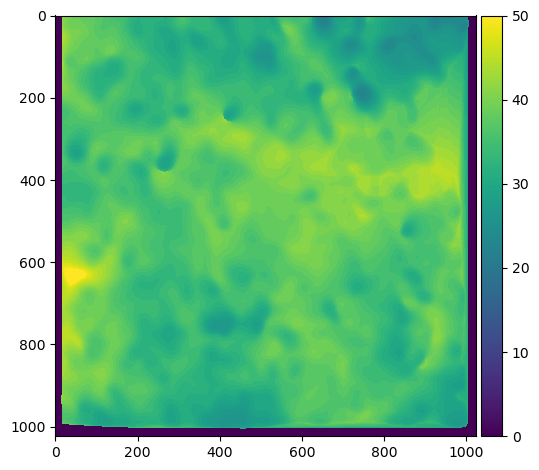

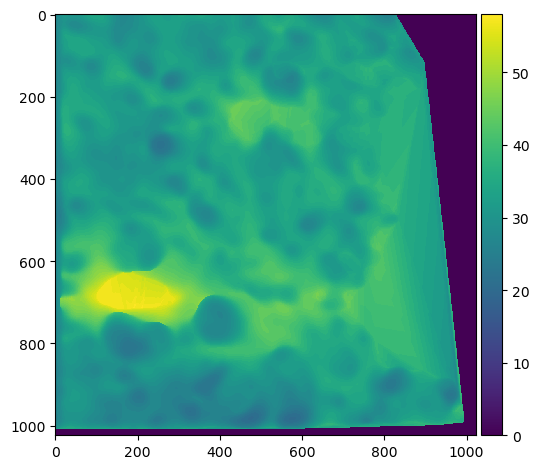

In [26]:
import stackview
io.imshow(heightmaps[0])
plt.figure()
io.imshow(heightmaps[1])

In [27]:
from measurements import get_tissue_curvature_over_grid,get_tissue_curvature_sparse

recalculate = False

dx = 0.583984375
dz = 3

mean_curve = {}
gaussian_curve = {}
for i,file in enumerate(filelist):
    print(file)        
    mesh = get_mesh_from_bm_image(height_images[i],
                                  spacing=[dz,dx,dx],decimation_factor=60)
    mean_curvature,gaussian_curvature = get_tissue_curvature_sparse(mesh,kappa=10,)
    export_mesh(mesh,file.parent / 'mesh.npz',values = mean_curvature)
    
    if not path.exists(file.parent / 'mean_curvature_kappa10.npz') or recalculate:
        mean_curvature,gaussian_curvature = \
            get_tissue_curvature_over_grid(mesh,image_shape=height_images[i].shape,kappa=10,)
        
        print(mean_curvature.shape)
        
        # os.makedirs(Path('/Users/xies/Desktop/F5')/ Path(file.parts[-4]) / Path(file.parts[-3]) / file.parent.name, exist_ok=True)
        np.savez(file.parent / 'mean_curvature_kappa10.npz',
                 mean_curvature=mean_curvature,gaussian_curvature=gaussian_curvature)
    

/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R1/B_unmixed.tif
(1024, 1024)
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R3/B_unmixed.tif
(1024, 1024)
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R4/B_unmixed.tif
(1024, 1024)
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R5/B_unmixed.tif
(1024, 1024)
/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Organoid/09-09-2026 Organoids 5perc GFP/organoid 1 24h/20x/R2/B_unmixed.tif
(1024, 1024)


In [88]:
# pl = pv.Plotter(notebook=True)
# mesh = Trimesh(v[:,[1,2,0]],f)
# pl.add_mesh(mesh)
# pl.show(jupyter_backend='trame')

In [47]:
# filelist

In [119]:
# Load single timepoint ones

from glob import glob
from pathlib import Path
from re import findall

dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1')
expt_name = ['Right ear/R2']
filelist = list(dirname.rglob( f'{expt_name[0]}/**/mean_curvature_kappa10.npz'))
# filelist = filelist + list(dirname.rglob( f'{expt_name[1]}/**/mean_curvature_kappa10.npz'))
print(filelist)

# Parse filename for time signature
manifest = pd.DataFrame()
manifest['filename'] = filelist
manifest['subdir_name'] = manifest['filename'].apply(lambda x: str(x.parent.name))
manifest['Delay'] = manifest['subdir_name'].apply(lambda x: int(findall(r'(\d+). Day (\d+)',x)[0][1]))
manifest['Region'] = manifest['filename'].apply(lambda x: x.parents[1].name)
manifest['Mouse'] = manifest['filename'].apply(lambda x: x.parents[2].name)
manifest['Experiment'] = manifest['filename'].apply(lambda x: x.parents[3].name)

manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['name'] = manifest['Mouse'] + '_' + manifest['Region'] + '_t' + manifest['Delay'].astype(str)
print(manifest)

curvatures = {}
for idx, row in manifest.iterrows():
    curvatures[row['Mouse_Region'], row['Delay']] = np.load(row['filename'])['mean_curvature']

# [x.shape for x in curvatures.values()]

[PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/1. Day 1/mean_curvature_kappa10.npz'), PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/2. Day 2/mean_curvature_kappa10.npz'), PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/4. Day 4/mean_curvature_kappa10.npz'), PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/0. Day 0/mean_curvature_kappa10.npz'), PosixPath('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Palbo senescence/F5 - 11-18-2025 H2B FUCCI Palbo-PG-DEGEE/M1/Right ear/R2/3. Day 3/mean_curvature_kappa10.npz'), PosixPath('/Users/xies/L

In [105]:
list(curvatures.keys())

[('Left ear_R2', 1)]

array([-1.67449531, -0.54555334,  0.0944696 , ...,  0.5581811 ,
        0.50719127,  0.5701386 ])